# Cornerstone — AI Engineer Starter Notebook

**Project:** Cornerstone (Coding Camp 2026, CC26-PRU462)

### Catatan penting

Notebook ini pake **dataset sintetis** (di-generate di Section 2) supaya:
1. Bisa langsung jalan tanpa nunggu tim DS selesai mengumpulkan dataset
2. Validasi pipeline preprocessing→model→training→inference jalan
3. Pas tim DS udah punya dataset asli, **Section 2 tinggal diganti** — sisanya nggak perlu diubah

## 1. Setup & Import


In [2]:
pip install tensorflow pandas scikit-learn matplotlib

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random
import json

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Generate Dataset Sintetis

Bikin dataset transaksi mock yang merepresentasikan deskripsi transaksi gaya Indonesia (gofood, gojek, dst).

**Catatan untuk tim:** Section ini nantinya **diganti** sama dataset asli dari tim DS. Format yang dibutuhkan:
- Kolom `description` (str): deskripsi transaksi mentah
- Kolom `category` (str): label kategori

In [4]:
CATEGORIES = {
    'Makanan_Minuman': {
        'merchants': ['mcd', 'kfc', 'starbucks', 'mixue', 'janji jiwa', 'kopi kenangan',
                      'warteg pak min', 'nasi padang sederhana', 'indomie warmindo',
                      'haus', 'chatime', 'pizza hut', 'dominos pizza', 'breadlife', 'jco donut',
                      'es teh indonesia', 'sate kambing', 'bakso pak gendut'],
        'prefixes': ['gofood', 'grabfood', 'shopeefood', 'pesan', 'beli', '', 'bayar'],
    },
    'Transportasi': {
        'merchants': ['gojek', 'grab', 'maxim', 'mrt jakarta', 'krl commuter', 'transjakarta',
                      'bensin pertamina', 'spbu shell', 'tol bekasi', 'tol cikampek',
                      'parkir mall', 'damri bandara', 'angkot'],
        'prefixes': ['', 'topup', 'isi saldo', 'bayar', 'gocar', 'grabcar', 'gobike'],
    },
    'Belanja': {
        'merchants': ['shopee', 'tokopedia', 'tiktok shop', 'lazada', 'bukalapak', 'uniqlo',
                      'h&m fashion', 'matahari dept', 'ace hardware', 'ikea', 'miniso', 'informa'],
        'prefixes': ['', 'belanja', 'order', 'transaksi', 'cod'],
    },
    'Tagihan': {
        'merchants': ['pln listrik', 'pdam air', 'indihome wifi', 'biznet', 'first media',
                      'bpjs kesehatan', 'telkomsel pulsa', 'xl axiata', 'pulsa indosat',
                      'kartu kredit bca', 'cicilan kpr btn'],
        'prefixes': ['bayar', 'tagihan', 'pembayaran', '', 'autodebet'],
    },
    'Hiburan': {
        'merchants': ['netflix', 'spotify premium', 'disney plus', 'youtube premium',
                      'cgv cinema', 'xxi bioskop', 'cinepolis', 'steam game',
                      'mobile legends diamond', 'apple music', 'amazon prime', 'wetv vip'],
        'prefixes': ['langganan', 'subscription', 'beli', '', 'topup'],
    },
    'Kesehatan': {
        'merchants': ['apotek kimia farma', 'apotek century', 'apotek k24', 'klinik medika',
                      'rs hermina', 'rs mitra keluarga', 'halodoc', 'alodokter', 'good doctor',
                      'klinik tongfang'],
        'prefixes': ['', 'beli obat', 'konsultasi', 'periksa', 'rawat jalan'],
    },
    'Pendidikan': {
        'merchants': ['ruangguru', 'zenius', 'skill academy', 'coursera', 'udemy',
                      'gramedia buku', 'tokobuku online', 'bimbel sscb', 'kursus bahasa inggris',
                      'duolingo plus'],
        'prefixes': ['langganan', 'beli', 'bayar kursus', '', 'kelas'],
    },
}

def generate_dataset(n_per_category=300):
    """Generate synthetic Indonesian-style transaction descriptions."""
    records = []
    for category, data in CATEGORIES.items():
        for _ in range(n_per_category):
            merchant = random.choice(data['merchants'])
            prefix = random.choice(data['prefixes'])
            description = f"{prefix} {merchant}".strip()
            # add realistic noise
            if random.random() < 0.25:
                description = description.upper()
            if random.random() < 0.15:
                description = description + f" {random.randint(1, 999)}"
            records.append({'description': description.lower(), 'category': category})
    return pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)

df = generate_dataset(n_per_category=300)
print(f"Dataset size: {len(df)} rows")
df.head(10)

Dataset size: 2100 rows


,description,category
0,tagihan kartu kredit bca,Tagihan
1,bayar indihome wifi,Tagihan
2,beli nasi padang sederhana,Makanan_Minuman
3,topup youtube premium,Hiburan
4,belanja bukalapak 158,Belanja
5,langganan bimbel sscb 188,Pendidikan
6,pembayaran pdam air,Tagihan
7,isi saldo spbu shell,Transportasi
8,mobile legends diamond,Hiburan
9,beli obat rs hermina,Kesehatan


Distribusi kategori:
category
Tagihan            300
Makanan_Minuman    300
Hiburan            300
Belanja            300
Pendidikan         300
Transportasi       300
Kesehatan          300
Name: count, dtype: int64


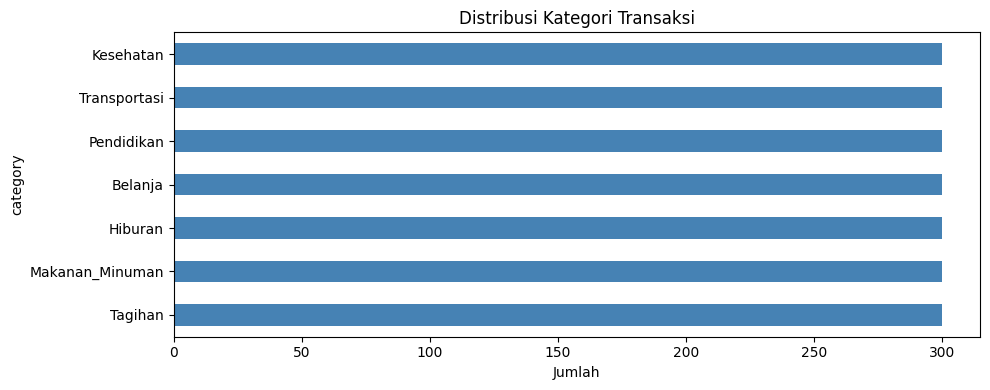

In [5]:
# Class distribution
print("Distribusi kategori:")
print(df['category'].value_counts())

plt.figure(figsize=(10, 4))
df['category'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Distribusi Kategori Transaksi')
plt.xlabel('Jumlah')
plt.tight_layout()
plt.show()

## 3. Preprocessing

Dua hal:
1. **Label encoding** — string kategori → integer
2. **Text vectorization** — string deskripsi → sequence of integers

Vectorizer kita pake `TextVectorization` layer dari Keras, **dimasukkan ke dalam model** (lihat Section 4)

In [6]:
# Label encoding
categories = sorted(df['category'].unique())
cat_to_id = {c: i for i, c in enumerate(categories)}
id_to_cat = {i: c for c, i in cat_to_id.items()}
df['label'] = df['category'].map(cat_to_id)
NUM_CLASSES = len(categories)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Mapping: {cat_to_id}")

Number of classes: 7
Mapping: {'Belanja': 0, 'Hiburan': 1, 'Kesehatan': 2, 'Makanan_Minuman': 3, 'Pendidikan': 4, 'Tagihan': 5, 'Transportasi': 6}


In [7]:
# Text vectorizer
MAX_TOKENS = 1000  # vocab size cap
MAX_LEN = 16       # max sequence length

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
)

# Fit ke training corpus
vectorizer.adapt(df['description'].values)
VOCAB_SIZE = len(vectorizer.get_vocabulary())
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sample vocab: {vectorizer.get_vocabulary()[:20]}")

Vocabulary size: 439
Sample vocab: ['', '[UNK]', np.str_('beli'), np.str_('bayar'), np.str_('langganan'), np.str_('topup'), np.str_('apotek'), np.str_('kursus'), np.str_('autodebet'), np.str_('rawat'), np.str_('jalan'), np.str_('cod'), np.str_('plus'), np.str_('konsultasi'), np.str_('rs'), np.str_('saldo'), np.str_('isi'), np.str_('belanja'), np.str_('transaksi'), np.str_('subscription')]


In [8]:
# Train/val split (stratified)
X = df['description'].values
y = df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tf.string tensors — penting karena Input layer expect string
X_train_t = tf.constant(X_train.reshape(-1, 1))
X_val_t = tf.constant(X_val.reshape(-1, 1))

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")

Train size: 1680
Val size:   420


## 4. Model Architecture (TensorFlow Functional API)

**Main Quest:** *Membangun model Deep Learning menggunakan TensorFlow Functional API atau Model Subclassing.*

Pola Functional API: setiap layer dipanggil sebagai fungsi terhadap layer sebelumnya — `x = layer(...)(x_prev)`. **Bukan** `model.add(...)` ala Sequential.

Arsitektur:
```
Input (string) → TextVectorization → Embedding → GlobalAveragePooling1D
                                                  → Dense(64, relu) → Dropout → Dense(num_classes, softmax)
```

Vectorizer di-embed ke dalam model supaya saat di-save & di-load di Streamlit, dia bisa langsung terima raw string input tanpa preprocessing manual.

In [9]:
def build_classifier(vectorizer, vocab_size, num_classes, embedding_dim=32):
    """
    Build text classifier using TensorFlow Functional API.

    Important: kita pake Functional API (BUKAN Sequential) karena:
    1. Required by Main Quest rubric
    2. Flexible — bisa multi-input/multi-output kalo nanti dibutuhkan
    3. Lebih eksplisit nunjukin arsitektur
    """
    # Input layer accepts raw string
    text_input = layers.Input(shape=(1,), dtype=tf.string, name='transaction_text')

    # Functional API style: x = layer(...)(previous)
    x = vectorizer(text_input)
    x = layers.Embedding(vocab_size, embedding_dim, mask_zero=True, name='embedding')(x)
    x = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='category_output')(x)

    model = Model(inputs=text_input, outputs=outputs, name='cornerstone_classifier')
    return model

model = build_classifier(vectorizer, VOCAB_SIZE, NUM_CLASSES)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "cornerstone_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ transaction_text    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 16)        │          0 │ transaction_text… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 16, 32)    │     14,048 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 16)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 32)        │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,112 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_output     │ (None, 7)         │        455 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,615 (64.90 KB)

 Trainable params: 16,615 (64.90 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Custom Callback (Main Quest: komponen kustom lanjutan)

**Main Quest:** *Mengimplementasikan setidaknya satu komponen kustom lanjutan dalam proses pengembangan model, seperti: Custom Layer / Custom Loss Function / **Custom Callback**.*

Pilih Custom Callback karena paling natural fit buat use case ini. `TrainingMonitorCallback` kita lakukan tiga hal:

1. **Track best epoch** — simpan val_accuracy tertinggi & epoch-nya
2. **Detect overfitting** — kasih warning kalo gap antara train_acc dan val_acc terlalu lebar
3. **Smart early stopping** — stop kalo target accuracy tercapai **dan** sudah lewat minimum epochs (biar model nggak stop prematurely)

In [10]:
class TrainingMonitorCallback(tf.keras.callbacks.Callback):
    """
    Custom Callback untuk monitor training Cornerstone classifier.

    Args:
        target_acc: target val_accuracy untuk early stop (default 0.85, sesuai target proyek)
        min_epochs: minimum epoch sebelum boleh stop (cegah premature stop)
        overfit_threshold: gap train_acc - val_acc yang dianggap overfitting
        verbose: print log atau enggak
    """
    def __init__(self, target_acc=0.85, min_epochs=8, overfit_threshold=0.15, verbose=1):
        super().__init__()
        self.target_acc = target_acc
        self.min_epochs = min_epochs
        self.overfit_threshold = overfit_threshold
        self.verbose = verbose
        self.best_val_acc = 0.0
        self.best_epoch = 0
        self.epoch_log = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy', 0)
        train_acc = logs.get('accuracy', 0)
        gap = abs(train_acc - val_acc)

        # 1. Logging
        self.epoch_log.append({
            'epoch': epoch + 1,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'overfit_gap': gap,
        })

        # 2. Track best
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_epoch = epoch + 1

        # 3. Overfit warning
        if gap > self.overfit_threshold and self.verbose:
            print(f"  [WARN] Possible overfitting at epoch {epoch+1}: gap = {gap:.4f}")

        # 4. Smart early stop
        if val_acc >= self.target_acc and (epoch + 1) >= self.min_epochs:
            if self.verbose:
                print(f"\n>> Target val_accuracy {self.target_acc*100:.0f}% tercapai di epoch {epoch+1} "
                      f"(val_acc={val_acc:.4f}). Stopping training.")
            self.model.stop_training = True

## 6. Training

Pake Custom Callback kita + EarlyStopping bawaan Keras sebagai safety net.

In [11]:
monitor_cb = TrainingMonitorCallback(target_acc=0.85, min_epochs=8)

callbacks = [
    monitor_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
]

history = model.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nBest epoch: {monitor_cb.best_epoch}")
print(f"Best val_accuracy: {monitor_cb.best_val_acc:.4f}")

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4230 - loss: 1.9170  [WARN] Possible overfitting at epoch 1: gap = 0.2738
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6048 - loss: 1.8773 - val_accuracy: 0.8786 - val_loss: 1.7361
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9280 - loss: 1.4106 - val_accuracy: 0.9905 - val_loss: 0.9796
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9923 - loss: 0.6124 - val_accuracy: 1.0000 - val_loss: 0.3063
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9988 - loss: 0.1980 - val_accuracy: 1.0000 - val_loss: 0.1012
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0831 - val_accuracy: 1.0000 - val_loss: 0.0469
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0456 - val_accuracy: 1.0000 - val_loss: 0.0270
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0288 - val_accuracy: 1.0000 - val

## 7. Evaluation

Pake metrik yang udah disebut di Project Plan: **Accuracy, Precision, Recall, F1**.

In [12]:
val_loss, val_acc = model.evaluate(X_val_t, y_val, verbose=0)
print(f"Final val_loss:     {val_loss:.4f}")
print(f"Final val_accuracy: {val_acc:.4f}")
print()

y_pred = np.argmax(model.predict(X_val_t, verbose=0), axis=1)
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=categories))

Final val_loss:     0.0121
Final val_accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Belanja       1.00      1.00      1.00        60
        Hiburan       1.00      1.00      1.00        60
      Kesehatan       1.00      1.00      1.00        60
Makanan_Minuman       1.00      1.00      1.00        60
     Pendidikan       1.00      1.00      1.00        60
        Tagihan       1.00      1.00      1.00        60
   Transportasi       1.00      1.00      1.00        60

       accuracy                           1.00       420
      macro avg       1.00      1.00      1.00       420
   weighted avg       1.00      1.00      1.00       420



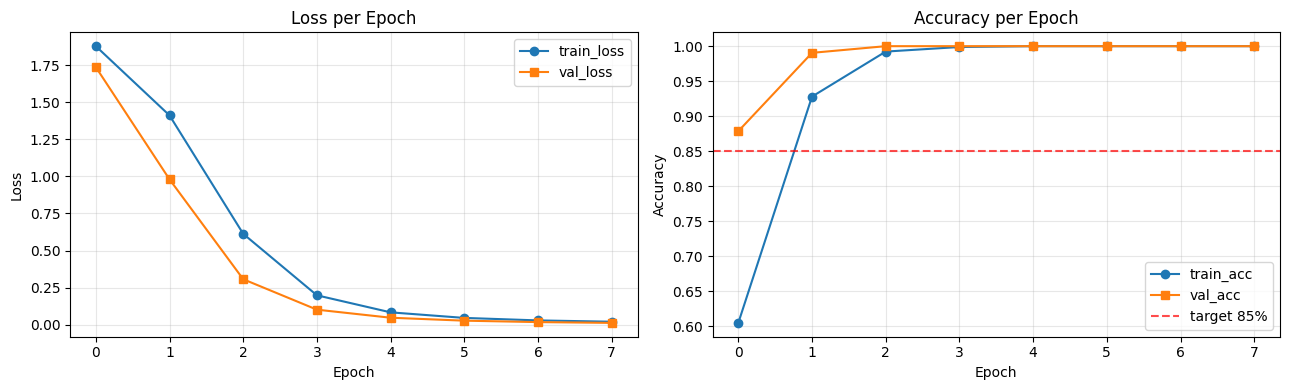

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='train_loss', marker='o')
axes[0].plot(history.history['val_loss'], label='val_loss', marker='s')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train_acc', marker='o')
axes[1].plot(history.history['val_accuracy'], label='val_acc', marker='s')
axes[1].axhline(y=0.85, color='red', linestyle='--', label='target 85%', alpha=0.7)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

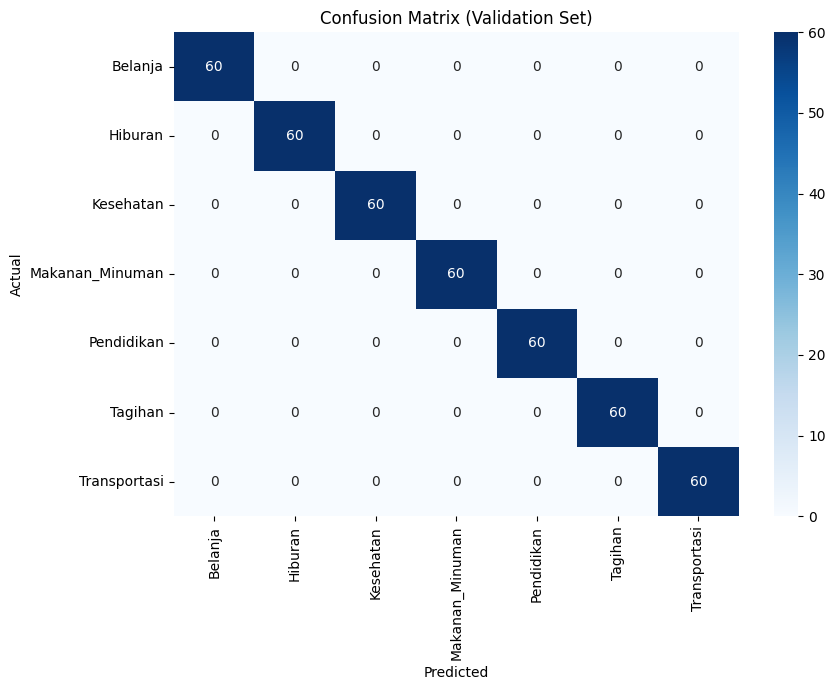

In [14]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 8. Save Model (Production-Ready Format)

**Main Quest:** *Menyimpan dan mengekspor model yang telah dilatih secara penuh dalam format TensorFlow siap produksi (`.keras` atau `SavedModel`).*

Kita save dua hal:
1. **Model file** (`.keras`) — bisa langsung di-load di Streamlit
2. **Category mapping** (`.json`) — buat decode prediction integer ke nama kategori

In [15]:
MODEL_PATH = 'cornerstone_classifier.keras'
MAPPING_PATH = 'category_mapping.json'

# Save model
model.save(MODEL_PATH)
print(f"✓ Model saved → {MODEL_PATH}")

# Save mapping
with open(MAPPING_PATH, 'w') as f:
    json.dump({str(k): v for k, v in id_to_cat.items()}, f, indent=2)
print(f"✓ Mapping saved → {MAPPING_PATH}")

# Verify file size
import os
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"\nModel size: {size_kb:.1f} KB")

✓ Model saved → cornerstone_classifier.keras
✓ Mapping saved → category_mapping.json

Model size: 235.4 KB


## 9. Inference (Load & Predict)

**Main Quest:** *Membuat kode sederhana untuk proses inference model.*

Fungsi `classify_transaction()` di bawah adalah versi standalone yang nanti tinggal di-import ke dalam Streamlit app.

In [16]:
# Load model from disk (simulate production loading)
loaded_model = keras.models.load_model(MODEL_PATH)
with open(MAPPING_PATH) as f:
    loaded_mapping = {int(k): v for k, v in json.load(f).items()}

def classify_transaction(text, model=loaded_model, mapping=loaded_mapping):
    """
    Klasifikasi satu deskripsi transaksi.

    Args:
        text: deskripsi transaksi (str)

    Returns:
        dict dengan predicted_category, confidence, all_probabilities
    """
    text_input = tf.constant([[text]])
    probs = model.predict(text_input, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    return {
        'input': text,
        'predicted_category': mapping[pred_id],
        'confidence': float(probs[pred_id]),
        'all_probabilities': {mapping[i]: float(p) for i, p in enumerate(probs)},
    }

# Demo
test_inputs = [
    'gofood mcd',
    'bayar listrik pln',
    'shopee belanja baju lebaran',
    'gojek ke kantor',
    'netflix premium bulanan',
    'apotek beli paracetamol',
    'ruangguru langganan',
    'beli kopi starbucks vivo',
    'top up gopay 50000',
]

print("=== INFERENCE DEMO ===\n")
for t in test_inputs:
    r = classify_transaction(t)
    print(f"'{r['input']:<40}' → {r['predicted_category']:<18} ({r['confidence']*100:.1f}%)")

=== INFERENCE DEMO ===

'gofood mcd                              ' → Makanan_Minuman    (99.8%)
'bayar listrik pln                       ' → Tagihan            (97.7%)
'shopee belanja baju lebaran             ' → Belanja            (93.7%)
'gojek ke kantor                         ' → Transportasi       (72.4%)
'netflix premium bulanan                 ' → Hiburan            (98.5%)
'apotek beli paracetamol                 ' → Kesehatan          (86.8%)
'ruangguru langganan                     ' → Pendidikan         (99.5%)
'beli kopi starbucks vivo                ' → Makanan_Minuman    (94.0%)
'top up gopay 50000                      ' → Makanan_Minuman    (29.2%)


## 10. Recap — Main Quest Status

| # | Requirement | Status | Cell |
|---|---|---|---|
| 1 | Functional API / Subclassing | ✅ | Section 4 |
| 2 | Komponen kustom (Custom Callback) | ✅ | Section 5 |
| 3 | Save model `.keras` | ✅ | Section 8 |
| 4 | Inference code | ✅ | Section 9 |

---

## Yang BELUM dilakukan & masih perlu

1. **Ganti dataset sintetis dengan dataset asli** dari tim DS (Section 2)
2. **Hyperparameter tuning** kalo accuracy di data asli kurang dari target
3. **Streamlit integration**
4. **Spending Leakage logic** kerjaan DS team (rumus matematis komparasi harga vs market benchmark)

---

*Notebook by AI Engineer 1 — Muhammad Daffa Ariq Fadilah*
*Cornerstone, CC26-PRU462*